In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_excel(r"C:\Users\MAHESHWARI\OneDrive\Documents\analysis Project\Unclean_Game_Dataset(U).xlsx")

# Basic Information
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

# Missing Values
print(df.isnull().sum())
df


   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii     NaN        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Release_Decade  \
0     41.49     29.02      3.77         8.46         82.74          2000.0   
1     29.08      3.58      6.81         0.77           NaN          1980.0   
2     15.85     12.88      3.79         3.31         35.82          2000.0   
3     15.75     11.01      3.28         2.96         33.00          2000.0   
4     11.27      8.89     10.22         1.00         31.37          1990.0   

  Sales_Category  NA_EU_Sales_Ratio  Is_Nintendo_Publisher  Lo

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Release_Decade,Sales_Category,NA_EU_Sales_Ratio,Is_Nintendo_Publisher,Log_Global_Sales,Dominant_Region
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,2000.0,Blockbuster,1.429211,1,4.427717,NaN
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,NaN,1980.0,Blockbuster,8.100279,1,3.719409,NaN
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,2000.0,Blockbuster,1.229635,1,3.606041,NaN
3,4,Wii Sports Resort,Wii,NaN,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,2000.0,Blockbuster,1.429220,1,3.526361,NaN
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1990.0,Blockbuster,1.266292,1,3.477232,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,NaN,0.00,0.00,0.00,0.01,2000.0,Low,1.000000,0,0.009950,NaN
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01,2000.0,Low,1.000000,0,0.009950,NaN
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01,2000.0,Low,0.000000,0,0.009950,NaN
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01,2010.0,Low,0.000000,0,0.009950,EU


In [3]:
print(df.isnull().sum())


Rank                         0
Name                         0
Platform                     0
Year                      1092
Genre                      814
Publisher                  886
NA_Sales                   829
EU_Sales                     0
JP_Sales                     0
Other_Sales                  0
Global_Sales               829
Release_Decade             268
Sales_Category               0
NA_EU_Sales_Ratio            0
Is_Nintendo_Publisher        0
Log_Global_Sales             0
Dominant_Region          10113
dtype: int64


In [4]:
df.dtypes

Rank                       int64
Name                      object
Platform                  object
Year                     float64
Genre                     object
Publisher                 object
NA_Sales                 float64
EU_Sales                 float64
JP_Sales                 float64
Other_Sales              float64
Global_Sales             float64
Release_Decade           float64
Sales_Category            object
NA_EU_Sales_Ratio        float64
Is_Nintendo_Publisher      int64
Log_Global_Sales         float64
Dominant_Region           object
dtype: object

In [5]:
df["Year"] = df["Year"].fillna(df["Year"].median())
df["Year"] = df["Year"].astype('Int64')

In [6]:
import numpy as np

cols = ['NA_Sales', 'EU_Sales','JP_Sales', 'Other_Sales', 'Global_Sales']

df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].round(1)
df[cols] = df[cols].apply(lambda row: row.fillna(row.median()), axis=1)
df[cols] = df[cols].fillna(df[cols].median())


In [7]:
df.isnull().sum()

Rank                         0
Name                         0
Platform                     0
Year                         0
Genre                      814
Publisher                  886
NA_Sales                     0
EU_Sales                     0
JP_Sales                     0
Other_Sales                  0
Global_Sales                 0
Release_Decade             268
Sales_Category               0
NA_EU_Sales_Ratio            0
Is_Nintendo_Publisher        0
Log_Global_Sales             0
Dominant_Region          10113
dtype: int64

In [8]:
df["Genre"] = df["Genre"].fillna(df["Genre"].mode()[0])
df["Publisher"] = df["Genre"].fillna(df["Publisher"].mode()[0])

In [9]:
df["Release_Decade"] = (df["Year"] // 10) *10

In [10]:
df["Dominant_Region"] = df["Dominant_Region"].fillna("India",limit = 502)

In [11]:
df["Dominant_Region"] = df["Dominant_Region"].fillna("EU",limit = 502)

In [12]:
df["Dominant_Region"] = df["Dominant_Region"].fillna("Other",limit = 502)

In [13]:
df["Dominant_Region"] = df["Dominant_Region"].fillna("JP",limit = 502)

In [14]:
df["Dominant_Region"] = df["Dominant_Region"].fillna("EU",limit = 5502)

In [15]:
df["Dominant_Region"] = df["Dominant_Region"].fillna("CA",limit=5502)

In [16]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Release_Decade',
       'Sales_Category', 'NA_EU_Sales_Ratio', 'Is_Nintendo_Publisher',
       'Log_Global_Sales', 'Dominant_Region'],
      dtype='object')

In [17]:
# Top 10 Games by Global Sales
top_games = df.sort_values("Global_Sales", ascending=False).head(10)
print(top_games[['Name','Global_Sales']])

                         Name  Global_Sales
0                  Wii Sports          82.7
2              Mario Kart Wii          35.8
3           Wii Sports Resort          33.0
4    Pokemon Red/Pokemon Blue          31.4
5                      Tetris          30.3
6       New Super Mario Bros.          30.0
7                    Wii Play          29.0
8   New Super Mario Bros. Wii          28.6
9                   Duck Hunt          28.3
10                 Nintendogs          24.8


In [18]:
# Top 10 Publishers
top_publishers = df['Publisher'].value_counts().head(10)

print(top_publishers)


Publisher
Action          3903
Sports          2186
Misc            1638
Role-Playing    1379
Shooter         1224
Adventure       1186
Racing          1154
Platform         825
Simulation       813
Fighting         800
Name: count, dtype: int64


In [19]:
# Sales by Genre
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
print(genre_sales)

Genre
Action           1889.50
Sports           1183.15
Shooter           911.75
Role-Playing      812.00
Misc              713.30
Platform          696.95
Racing            662.05
Fighting          411.60
Simulation        345.30
Puzzle            218.35
Adventure         191.45
Strategy          142.95
ACTION             59.60
SHOOTER            38.40
PLATFORM           29.60
ROLE-PLAYING       20.00
SPORTS             14.05
PUZZLE              9.00
RACING              8.15
SIMULATION          5.95
STRATEGY            4.95
MISC                4.80
NAN                 4.40
FIGHTING            3.60
ADVENTURE           1.70
Name: Global_Sales, dtype: float64


In [20]:
# Sales by Platform
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)
print(platform_sales)


Platform
PS2     1189.90
X360     912.80
PS3      905.50
Wii      899.40
DS       774.25
PS       688.60
GBA      299.90
PSP      270.45
PS4      257.95
GB       248.30
PC       241.00
XB       236.50
3DS      233.80
NES      210.80
SNES     197.35
N64      189.10
GC       187.50
XOne     133.20
2600      94.45
WiiU      79.15
PSV       54.75
SAT       33.50
GEN       24.50
DC        15.20
SCD        1.80
WS         1.40
NG         1.30
3DO        0.10
TG16       0.10
PCFX       0.00
GG         0.00
Name: Global_Sales, dtype: float64


In [21]:
# Sales by Platform
Name = df.groupby('Name')['Global_Sales'].sum().sort_values(ascending=False)
print(Name)


Name
Wii Sports                             82.7
Grand Theft Auto V                     56.0
Tetris                                 35.9
Mario Kart Wii                         35.8
Wii Sports Resort                      33.0
                                       ... 
Fire Emblem: Awakening                 -2.0
Halo Wars                              -2.6
Cooking Mama 2: Dinner With Friends    -3.6
EyeToy Play                            -4.2
Kingdom Hearts                         -4.6
Name: Global_Sales, Length: 11453, dtype: float64


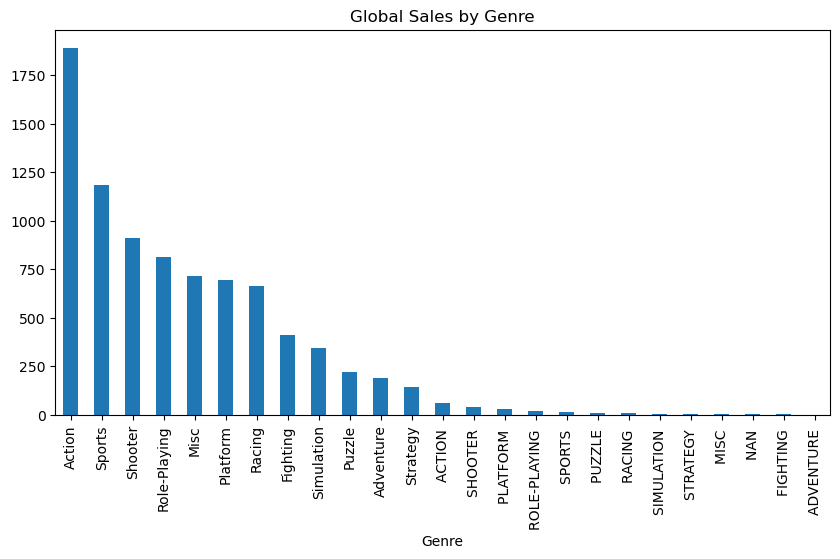

In [22]:
# Visualization

# Genre Sales Bar Chart
genre_sales.plot(kind='bar', figsize=(10,5), title="Global Sales by Genre")
plt.show()



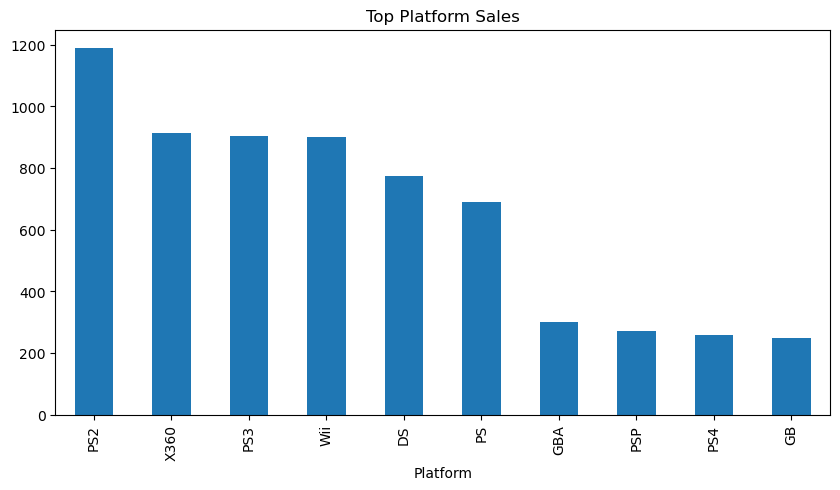

In [23]:
# Platform Sales Bar Chart
platform_sales.head(10).plot(kind='bar', figsize=(10,5), title="Top Platform Sales")
plt.show()

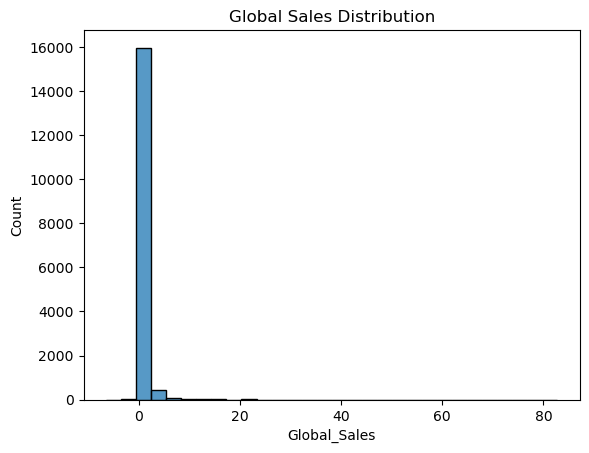

In [24]:
# Sales Distribution
sns.histplot(df['Global_Sales'], bins=30)
plt.title("Global Sales Distribution")


plt.show()

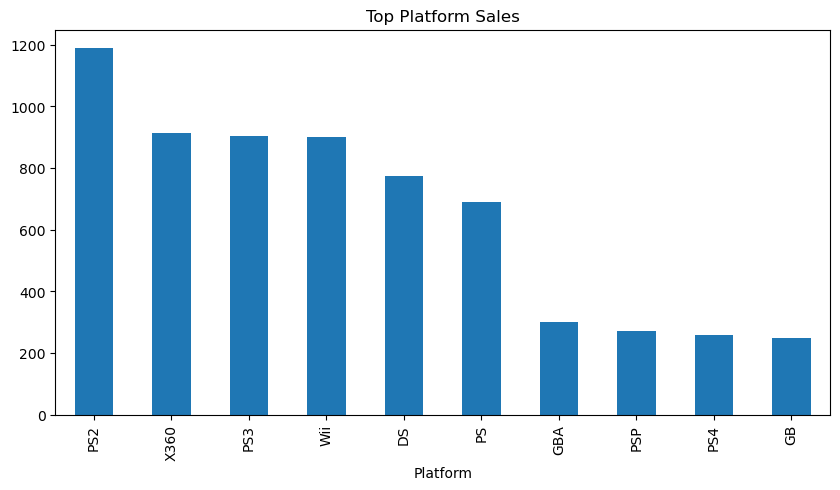

In [25]:
# Platform Sales Bar Chart
platform_sales.head(10).plot(kind='bar', figsize=(10,5), title="Top Platform Sales")
plt.show()

In [26]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Release_Decade,Sales_Category,NA_EU_Sales_Ratio,Is_Nintendo_Publisher,Log_Global_Sales,Dominant_Region
0,1,Wii Sports,Wii,2006,Sports,Sports,41.5,29.0,3.8,8.5,82.7,2000,Blockbuster,1.429211,1,4.427717,India
1,2,Super Mario Bros.,NES,1985,Platform,Platform,29.1,3.6,6.8,0.8,5.2,1980,Blockbuster,8.100279,1,3.719409,India
2,3,Mario Kart Wii,Wii,2008,Racing,Racing,15.8,12.9,3.8,3.3,35.8,2000,Blockbuster,1.229635,1,3.606041,India
3,4,Wii Sports Resort,Wii,2007,Sports,Sports,15.8,11.0,3.3,3.0,33.0,2000,Blockbuster,1.429220,1,3.526361,India
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Role-Playing,11.3,8.9,10.2,1.0,31.4,1990,Blockbuster,1.266292,1,3.477232,India


In [27]:
print(df.isnull().sum())

Rank                     0
Name                     0
Platform                 0
Year                     0
Genre                    0
Publisher                0
NA_Sales                 0
EU_Sales                 0
JP_Sales                 0
Other_Sales              0
Global_Sales             0
Release_Decade           0
Sales_Category           0
NA_EU_Sales_Ratio        0
Is_Nintendo_Publisher    0
Log_Global_Sales         0
Dominant_Region          0
dtype: int64


In [28]:
cd C:\Users\MAHESHWARI\OneDrive\Documents\analysis Project

C:\Users\MAHESHWARI\OneDrive\Documents\analysis Project


In [29]:
df.to_csv("VideoGameClean.csv",index=False)

In [30]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Release_Decade,Sales_Category,NA_EU_Sales_Ratio,Is_Nintendo_Publisher,Log_Global_Sales,Dominant_Region
0,1,Wii Sports,Wii,2006,Sports,Sports,41.5,29.0,3.8,8.5,82.7,2000,Blockbuster,1.429211,1,4.427717,India
1,2,Super Mario Bros.,NES,1985,Platform,Platform,29.1,3.6,6.8,0.8,5.2,1980,Blockbuster,8.100279,1,3.719409,India
2,3,Mario Kart Wii,Wii,2008,Racing,Racing,15.8,12.9,3.8,3.3,35.8,2000,Blockbuster,1.229635,1,3.606041,India
3,4,Wii Sports Resort,Wii,2007,Sports,Sports,15.8,11.0,3.3,3.0,33.0,2000,Blockbuster,1.429220,1,3.526361,India
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Role-Playing,11.3,8.9,10.2,1.0,31.4,1990,Blockbuster,1.266292,1,3.477232,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Platform,0.0,0.0,0.0,0.0,0.0,2000,Low,1.000000,0,0.009950,CA
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Shooter,0.0,0.0,0.0,0.0,0.0,2000,Low,1.000000,0,0.009950,CA
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Racing,0.0,0.0,0.0,0.0,0.0,2000,Low,0.000000,0,0.009950,CA
16596,16599,Know How 2,DS,2010,Puzzle,Puzzle,0.0,0.0,0.0,0.0,0.0,2010,Low,0.000000,0,0.009950,EU
